 # GROMACS 2026.1 Installation with CUDA Support on Colab

 This notebook outlines the steps to install GROMACS 2026.1 from source with CUDA support. This setup is compatible with NVIDIA GPUs available in Colab environments.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


 ## 1. Install Build Dependencies
 Ensure necessary build tools like `cmake` and `build-essential` are installed.

In [ ]:
import os

# Update apt and install essential build tools
!sudo apt-get update
!sudo apt-get install -y build-essential cmake

# Install FFTW (Fastest Fourier Transform in the West) which GROMACS often uses for performance
!sudo apt-get install -y libfftw3-dev

# Set GROMACS installation directory to a persistent location on Google Drive
GMX_INSTALL_DIR = "/content/drive/MyDrive/gromacs_persistent"
os.makedirs(GMX_INSTALL_DIR, exist_ok=True)

print(f"GROMACS will be installed to: {GMX_INSTALL_DIR}")

Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,608 kB]
Get:5 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Hit:9 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,990 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,864 kB]
Get:13 https://ppa.launchpadcontent.net/deadsnakes

 ## 2. Check CUDA and CMake Versions
 Verify the versions of `nvcc` (NVIDIA CUDA Compiler) and `cmake`.

In [ ]:
!nvcc --version
!cmake --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0
cmake version 3.31.10

CMake suite maintained and supported by Kitware (kitware.com/cmake).


 ## 3. Download GROMACS Source Code
 Download the GROMACS 2026.1 source tarball and extract it.

In [ ]:
GMX_VERSION = "2026.1"
GMX_TARBALL = f"gromacs-{GMX_VERSION}.tar.gz"
GMX_SRC_DIR = f"gromacs-{GMX_VERSION}"

!wget -q https://ftp.gromacs.org/pub/gromacs/{GMX_TARBALL}
!tar xzf {GMX_TARBALL}

print(f"GROMACS source downloaded and extracted to: {GMX_SRC_DIR}")

GROMACS source downloaded and extracted to: gromacs-2026.1


 ## 4. Configure GROMACS with CMake for CUDA
 Create a build directory and configure GROMACS using `cmake`. Important flags for GPU acceleration are `GMX_GPU=CUDA`.

 Note: Using `ON` for `GMX_BUILD_MPI` is optional but recommended for large simulations if you have multiple GPUs or are using MPI.
 `CMAKE_INSTALL_PREFIX` specifies the installation directory.

In [ ]:
build_dir = "build"
os.makedirs(build_dir, exist_ok=True)
os.chdir(build_dir)

!cmake ../{GMX_SRC_DIR} -DGMX_GPU=CUDA -DCMAKE_INSTALL_PREFIX={GMX_INSTALL_DIR} -DGMX_BUILD_MPI=OFF -DGMX_DOUBLE=OFF -DREGRESSIONTEST_DOWNLOAD=OFF
# -DGMX_DOUBLE=OFF for single precision (faster for many applications)
# -DGMX_BUILD_MPI=ON if you want MPI support (requires OpenMPI libs)
# -DREGRESSIONTEST_DOWNLOAD=OFF to skip downloading regression test data during build (can be slow)

print("CMake configuration complete.")

-- The C compiler identification is GNU 11.4.0
-- The CXX compiler identification is GNU 11.4.0
-- Detecting C compiler ABI info
-- Detecting C compiler ABI info - done
-- Check for working C compiler: /usr/bin/cc - skipped
-- Detecting C compile features
-- Detecting C compile features - done
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
-- Check for working CXX compiler: /usr/bin/c++ - skipped
-- Detecting CXX compile features
-- Detecting CXX compile features - done
-- Found Python3: /usr/local/bin/python (found suitable version "3.12.13", minimum required is "3.9") found components: Interpreter Development Development.Module Development.Embed
-- Selected GPU FFT library - cuFFT
-- Found OpenMP_CXX: -fopenmp (found version "4.5")
-- Found OpenMP: TRUE (found version "4.5") found components: CXX
-- Performing Test CFLAGS_WARN_NO_MISSING_FIELD_INITIALIZERS
-- Performing Test CFLAGS_WARN_NO_MISSING_FIELD_INITIALIZERS - Success
-- Performing Test CFLAGS_EX

 ## 5. Build and Install GROMACS
 Compile GROMACS using `make` and then install it. This step can take a while.

In [ ]:
!make -j $(nproc) # Use all available CPU cores for compilation
!sudo make install

os.chdir('..') # Go back to the original directory

print("GROMACS compilation and installation complete.")

[  0%] Building CXX object src/gromacs/selection/CMakeFiles/scanner.dir/parser.cpp.o
[  0%] Building CXX object src/external/rpc_xdr/CMakeFiles/internal_rpc_xdr.dir/xdr.cpp.o
[  0%] Generating release version information
[  0%] Building CXX object src/gromacs/CMakeFiles/thread_mpi.dir/__/external/thread_mpi/src/errhandler.cpp.o
[  0%] Building CXX object src/gromacs/CMakeFiles/lmfit_objlib.dir/__/external/lmfit/lmmin.cpp.o
[  0%] Building C object src/gromacs/CMakeFiles/tng_io_obj.dir/__/external/tng_io/src/compression/bwlzh.c.o
[  0%] Building C object src/gromacs/CMakeFiles/tng_io_zlib.dir/__/external/tng_io/external/zlib/adler32.c.o
[  0%] Building CXX object src/gromacs/fmm/CMakeFiles/fmm.dir/fmm_mdmodule.cpp.o
[  0%] Building CXX object src/gromacs/CMakeFiles/colvars_objlib.dir/__/external/colvars/colvar.cpp.o
[  0%] Building CXX object _deps/muparser-build/CMakeFiles/muparser.dir/src/muParser.cpp.o
[  0%] Building CXX object src/gromacs/linearalgebra/CMakeFiles/linearalgebra.dir/

 ## 6. Set up Environment Variables
 Update the `PATH` and `LD_LIBRARY_PATH` environment variables so GROMACS can be found and executed from any directory.

In [ ]:
# Add GROMACS binaries to PATH
os.environ['PATH'] = f"{GMX_INSTALL_DIR}/bin:{os.environ['PATH']}"

# Add GROMACS libraries to LD_LIBRARY_PATH
os.environ['LD_LIBRARY_PATH'] = f"{GMX_INSTALL_DIR}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"

# Reload environment variables for the current session (for interactive use within the notebook)
!source {GMX_INSTALL_DIR}/bin/GMXRC

print("Environment variables updated. You may need to restart the runtime or re-run this cell if `gmx` command isn't found immediately.")

Environment variables updated. You may need to restart the runtime or re-run this cell if `gmx` command isn't found immediately.


## Reusing GROMACS in a New Colab Session

Since GROMACS is now installed to your Google Drive, you can reuse it in subsequent Colab sessions without recompiling. Here are the steps you'll need to take at the beginning of a new session:

1.  **Mount Google Drive:** Run the `drive.mount('/content/drive')` command.
2.  **Define GMX_INSTALL_DIR:** Set the `GMX_INSTALL_DIR` variable to your installation path on Google Drive.
3.  **Set Environment Variables:** Source the `GMXRC` file to update your `PATH` and `LD_LIBRARY_PATH`.
4.  **Verify Installation:** Run `gmx --version` to confirm GROMACS is accessible.

In [1]:
# Update apt and install essential build tools
!sudo apt-get update
!sudo apt-get install -y build-essential cmake

# Install FFTW (Fastest Fourier Transform in the West) which GROMACS often uses for performance
!sudo apt-get install -y libfftw3-dev

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,237 kB]
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,601 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/multiverse amd64 Packages [86.0 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-update

In [2]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 2. Define GMX_INSTALL_DIR
GMX_INSTALL_DIR = "/content/drive/MyDrive/gromacs_persistent"

# 3. Set Environment Variables
os.environ['PATH'] = f"{GMX_INSTALL_DIR}/bin:{os.environ['PATH']}"
os.environ['LD_LIBRARY_PATH'] = f"{GMX_INSTALL_DIR}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"

# Enable execution permissions
!chmod +x /content/drive/MyDrive/gromacs_persistent/bin/gmx

# Source GMXRC for a complete setup (though environment variables are mostly handled above for python subprocesses)
# This is more for interactive shell contexts but good practice.
!source {GMX_INSTALL_DIR}/bin/GMXRC

print("GROMACS environment variables set for persistent installation.")

# 4. Verify Installation
!gmx --version

GROMACS environment variables set for persistent installation.
                         :-) GROMACS - gmx, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content
Command line:
  gmx --version

GROMACS version:     2026.1
Precision:           mixed
Memory model:        64 bit
MPI library:         thread_mpi
MPI version:         built in
OpenMP support:      enabled (GMX_OPENMP_MAX_THREADS = 128)
GPU support:         CUDA
NBNxM GPU setup:     super-cluster 2x2x2 / cluster 8 (cluster-pair splitting on)
SIMD instructions:   AVX_512
CPU FFT library:     fftw-3.3.8-sse2-avx
GPU FFT library:     cuFFT
Multi-GPU FFT:       none
RDTSCP:              enabled
TNG support:         enabled
Hwloc support:       disabled
Tracing support:     disabled
Colvars support:     enabled (version 2025-10-13)
CP2K support:        disabled
Torch support:       disabled
Plumed support:      enabled
C compiler:    

 ## 7. Verify GROMACS Installation
 Run the `gmx` command to check the installed version and ensure it's working correctly. Look for CUDA or GPU in the output to confirm GPU support.

In [ ]:
!gmx help
!gmx --version

                       :-) GROMACS - gmx help, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content
Command line:
  gmx help

SYNOPSIS

gmx [-[no]h] [-[no]quiet] [-[no]version] [-[no]copyright] [-nice <int>]
    [-[no]backup]

OPTIONS

Other options:

 -[no]h                     (no)
           Print help and quit
 -[no]quiet                 (no)
           Do not print common startup info or quotes
 -[no]version               (no)
           Print extended version information and quit
 -[no]copyright             (no)
           Print copyright information on startup
 -nice   <int>              (19)
           Set the nicelevel (default depends on command)
 -[no]backup                (yes)
           Write backups if output files exist

Additional help is available on the following topics:
    commands    List of available commands
    selections  Selection syntax and usage
To access t

In [4]:
# Set the working directory
%cd /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main\ 2

/content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2


In [ ]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} grompp -f MD.mdp -c NPT.gro -t NPT.cpt -p topol.top -n index.ndx -maxwarn 2 -o MD.tpr

                      :-) GROMACS - gmx grompp, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx grompp -f MD.mdp -c NPT.gro -t NPT.cpt -p topol.top -n index.ndx -maxwarn 2 -o MD.tpr

Ignoring obsolete mdp entry 'title'
Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -914902082

Generated 21321 of the 21321 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 1

Generated 18210 of the 21321 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'Protein_chain_A'

turning H bonds into constraints...

Excluding 3 bonded neighbours molecule type 'LIG'

turning H bonds into constraints...

Excluding 2 bonded neighbours molecule type 'SOL'

turning H bonds into constraints...

Excluding 1 bonded neighbours molecule type 'NA'

turning H bonds into constraints...


In [5]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} mdrun -deffnm MD \
  -cpi MD.cpt \
  -nb gpu -pme gpu -update gpu \
  -ntmpi 1 -ntomp 12 \
  -pin on -tunepme -dlb auto \
  -cpt 5 -append -v

                      :-) GROMACS - gmx mdrun, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx mdrun -deffnm MD -cpi MD.cpt -nb gpu -pme gpu -update gpu -ntmpi 1 -ntomp 12 -pin on -tunepme -dlb auto -cpt 5 -append -v

Reading file MD.tpr, VERSION 2026.1 (single precision)
Changing nstlist from 20 to 100, rlist from 1.218 to 1.356

Update groups can not be used for this system because atoms that are (in)directly constrained together are interdispersed with other atoms

1 GPU selected for this run.
Mapping of GPU IDs to the 2 GPU tasks in the 1 rank on this node:
  PP:0,PME:0
PP tasks will do non-perturbed short-ranged interactions on the GPU
PP task will update and constrain coordinates on the GPU
PME tasks will do all aspects on the GPU
Using 1 MPI thread
Using 12 OpenMP threads 

starting mdrun 'Protein in wa

In [ ]:
# The 'mdrun' commands below would overwrite MD.xtc if not used with '-append' and a checkpoint file.
# If you need to continue a simulation, ensure to use the '-cpi' and '-append' flags correctly.
# The 100ns simulation was already completed by the 'mdrun' command in cell '2t4-8eD8Tfve'.
# Please re-run the 'mdrun' command in cell '2t4-8eD8Tfve' to ensure the full 100ns trajectory is generated correctly.
# If you intend to run further 10ns segments, ensure your command looks similar to cell 2t4-8eD8Tfve.

# Removed: GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
# Removed: !{GMX_BIN} mdrun -deffnm MD -cpi MD.cpt -nsteps 10000000 \
# Removed:   -nb gpu -pme gpu -pmefft gpu -ntomp 12 -pin on

# Removed: !{GMX_BIN} mdrun -deffnm MD -nsteps 10000000 \
# Removed:   -nb gpu -pme gpu -pmefft gpu -ntomp 16 -pin on -v

In [6]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} trjcat -f MD.xtc -o MD_full.xtc -cat

                      :-) GROMACS - gmx trjcat, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx trjcat -f MD.xtc -o MD_full.xtc -cat

Note that major changes are planned in future for trjcat, to improve usability and utility.
Reading frame       1 time   10.000   

Summary of files and start times used:

          File                Start time       Time step
---------------------------------------------------------
                   MD.xtc        0.000 ps       10.000 ps

Reading frame       0 time    0.000   
lasttime 0

Continue writing frames from MD.xtc t=0 ps, frame=0      
Reading frame    2000 time 20000.000    ->  frame   2000 time 20000.000 ps     

Last frame written was 2037, time 20370.000000 ps

GROMACS reminds you: "C is not a high-level language." (Brian Kernighan, C author)



### Identify and Concatenate Full Trajectory

Given the `mdrun` output indicating a 100ns simulation, but `trjcat` only processing 20ns, it's possible the trajectory data is split across multiple files (e.g., `MD.xtc`, `MD.part0001.xtc`, etc.) or `MD.xtc` was not fully updated. To ensure we have the complete 100ns trajectory for analysis, we'll first list all `.xtc` files and then use `gmx trjcat` to combine them.

In [8]:
# List all .xtc files in the current directory
!ls *.xtc

MD_center.xtc  MD_full.xtc  MD.xtc  NPT.xtc  NVT.xtc


Based on the output above, you should replace the list of `.xtc` files in the `-f` flag below to include all relevant trajectory files. For example, if you see `MD.xtc` and `MD.part0001.xtc`, use `MD.xtc MD.part0001.xtc`.

In [9]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"

# Concatenate all .xtc files into a single full trajectory
# IMPORTANT: Replace `MD.xtc` with the actual list of all .xtc files found in the previous step, e.g., 'MD.xtc MD.part0001.xtc'
!{GMX_BIN} trjcat -f MD.xtc -o MD_full.xtc -cat

                      :-) GROMACS - gmx trjcat, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx trjcat -f MD.xtc -o MD_full.xtc -cat

Note that major changes are planned in future for trjcat, to improve usability and utility.
Reading frame       1 time   10.000   

Summary of files and start times used:

          File                Start time       Time step
---------------------------------------------------------
                   MD.xtc        0.000 ps       10.000 ps


Back Off! I just backed up MD_full.xtc to ./#MD_full.xtc.1#
Reading frame       0 time    0.000   
lasttime 0

Continue writing frames from MD.xtc t=0 ps, frame=0      
Reading frame    2000 time 20000.000    ->  frame   2000 time 20000.000 ps     

Last frame written was 2037, time 20370.000000 ps

GROMACS reminds you: "Not to get techni

Now that `MD_full.xtc` should contain the complete 100ns trajectory, you can re-run the verification and analysis steps (recentering, rewrapping, RMSD, RMSF, H-bond analysis) with this updated file.

In [10]:
!{GMX_BIN} check -f MD_full.xtc

                      :-) GROMACS - gmx check, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx check -f MD_full.xtc

Checking file MD_full.xtc
Reading frame       0 time    0.000   
# Atoms  65169
Precision 0.001 (nm)
Reading frame    2000 time 20000.000   


Item        #frames Timestep (ps)
Step          2038    10
Time          2038    10
Lambda           0
Coords        2038    10
Velocities       0
Forces           0
Box           2038    10

GROMACS reminds you: "It's an easy game, just don't let the ball past!" (Szilard Pall)



In [11]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} trjconv -s MD.tpr -f MD.xtc -o MD_center.xtc -center -pbc mol -ur compact

                     :-) GROMACS - gmx trjconv, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx trjconv -s MD.tpr -f MD.xtc -o MD_center.xtc -center -pbc mol -ur compact

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write xtc: Compressed trajectory (portable xdr format): xtc
Reading file MD.tpr, VERSION 2026.1 (single precision)
Reading file MD.tpr, VERSION 2026.1 (single precision)
Select group for centering
Group     0 (         System) has 65169 elements
Group     1 (        Protein) has  9405 elements
Group     2 (      Protein-H) has  4835 elements
Group     3 (        C-alpha) has   586 elements
Group     4 (       Backbone) has  1758 elements
Group     5 (      MainChain) has  2343 elements
Group     6 (   MainChain+Cb) has  2896 elements
Group     7 

In [12]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} trjconv -s MD.tpr -f MD_center.xtc -o start.pdb -dump 0

                     :-) GROMACS - gmx trjconv, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx trjconv -s MD.tpr -f MD_center.xtc -o start.pdb -dump 0

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write pdb: Protein data bank file
Reading file MD.tpr, VERSION 2026.1 (single precision)
Reading file MD.tpr, VERSION 2026.1 (single precision)
Select group for output
Group     0 (         System) has 65169 elements
Group     1 (        Protein) has  9405 elements
Group     2 (      Protein-H) has  4835 elements
Group     3 (        C-alpha) has   586 elements
Group     4 (       Backbone) has  1758 elements
Group     5 (      MainChain) has  2343 elements
Group     6 (   MainChain+Cb) has  2896 elements
Group     7 (    MainChain+H) has  2901 elements
Group     

In [13]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} rms -s MD.tpr -f MD_center.xtc -o rmsd.xvg -tu ns

                       :-) GROMACS - gmx rms, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx rms -s MD.tpr -f MD_center.xtc -o rmsd.xvg -tu ns

Reading file MD.tpr, VERSION 2026.1 (single precision)
Reading file MD.tpr, VERSION 2026.1 (single precision)
Select group for least squares fit
Group     0 (         System) has 65169 elements
Group     1 (        Protein) has  9405 elements
Group     2 (      Protein-H) has  4835 elements
Group     3 (        C-alpha) has   586 elements
Group     4 (       Backbone) has  1758 elements
Group     5 (      MainChain) has  2343 elements
Group     6 (   MainChain+Cb) has  2896 elements
Group     7 (    MainChain+H) has  2901 elements
Group     8 (      SideChain) has  6504 elements
Group     9 (    SideChain-H) has  2492 elements
Group    10 (    Prot-Masses) has  9405 e

In [9]:
!xmgrace rmsd.xvg

/bin/bash: line 1: xmgrace: command not found


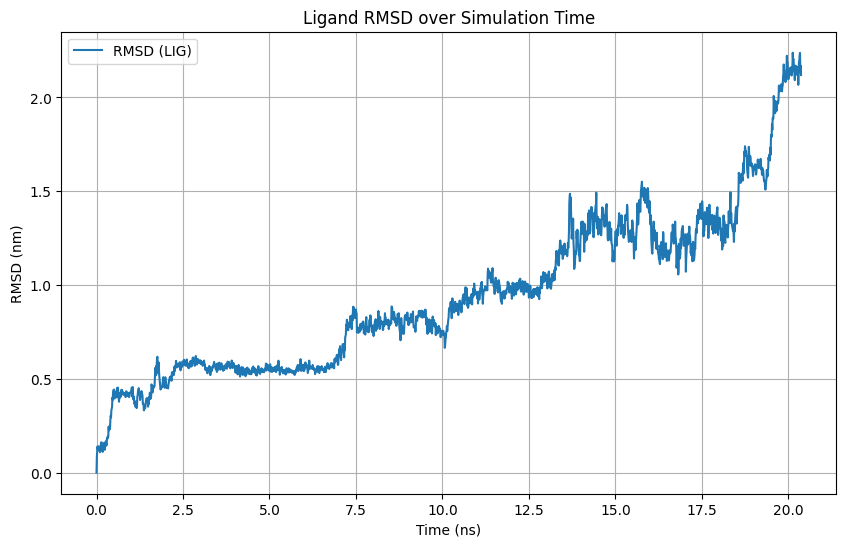

RMSD data plotted from rmsd.xvg


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Define the path to the rmsd.xvg file
rmsd_file = 'rmsd.xvg'

# Initialize lists to store time and RMSD data
time = []
rmsd = []

# Read the data from the .xvg file, skipping comments
with open(rmsd_file, 'r') as f:
    for line in f:
        if line.startswith('#') or line.startswith('@'):
            continue
        parts = line.split()
        if len(parts) == 2:
            try:
                time.append(float(parts[0]))
                rmsd.append(float(parts[1]))
            except ValueError:
                # Skip lines that can't be converted to float
                continue

# Plot the RMSD data
plt.figure(figsize=(10, 6))
plt.plot(time, rmsd, label='RMSD (LIG)')
plt.xlabel('Time (ns)')
plt.ylabel('RMSD (nm)')
plt.title('Ligand RMSD over Simulation Time')
plt.grid(True)
plt.legend()
plt.show()

print(f"RMSD data plotted from {rmsd_file}")

In [15]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} rmsf -s MD.tpr -f MD_center.xtc -o rmsf.xvg

                       :-) GROMACS - gmx rmsf, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx rmsf -s MD.tpr -f MD_center.xtc -o rmsf.xvg

Reading file MD.tpr, VERSION 2026.1 (single precision)
Reading file MD.tpr, VERSION 2026.1 (single precision)
Select group(s) for root mean square calculation
Group     0 (         System) has 65169 elements
Group     1 (        Protein) has  9405 elements
Group     2 (      Protein-H) has  4835 elements
Group     3 (        C-alpha) has   586 elements
Group     4 (       Backbone) has  1758 elements
Group     5 (      MainChain) has  2343 elements
Group     6 (   MainChain+Cb) has  2896 elements
Group     7 (    MainChain+H) has  2901 elements
Group     8 (      SideChain) has  6504 elements
Group     9 (    SideChain-H) has  2492 elements
Group    10 (    Prot-Masses) ha

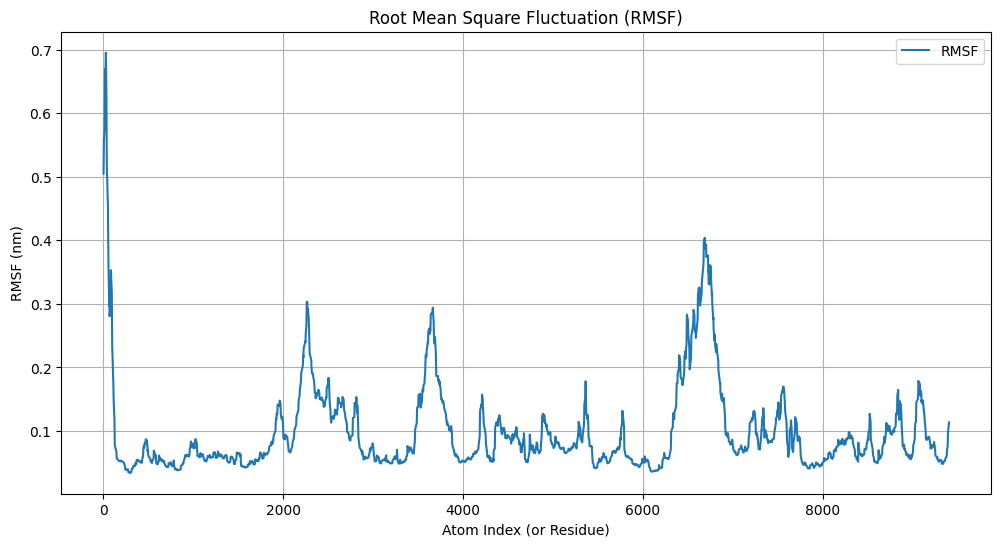

RMSF data plotted from rmsf.xvg


In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Define the path to the rmsf.xvg file
output_file = 'rmsf.xvg'

# Initialize lists to store atom index and RMSF data
atom_indices = []
rmsf_values = []

# Read the data from the .xvg file, skipping comments
with open(output_file, 'r') as f:
    for line in f:
        if line.startswith('#') or line.startswith('@'):
            continue
        parts = line.split()
        if len(parts) == 2:
            try:
                # Assuming the first column is atom index/residue and second is RMSF
                atom_indices.append(int(parts[0]))
                rmsf_values.append(float(parts[1]))
            except ValueError:
                # Skip lines that can't be converted to float/int
                continue

# Plot the RMSF data
plt.figure(figsize=(12, 6))
plt.plot(atom_indices, rmsf_values, label='RMSF')
plt.xlabel('Atom Index (or Residue)')
plt.ylabel('RMSF (nm)')
plt.title('Root Mean Square Fluctuation (RMSF)')
plt.grid(True)
plt.legend()
plt.show()

print(f"RMSF data plotted from {output_file}")

In [ ]:
GMX_BIN = f"{GMX_INSTALL_DIR}/bin/gmx"
!{GMX_BIN} hbond -s MD.tpr -f MD_center.xtc -num hb.xvg -tu ns

                      :-) GROMACS - gmx hbond, 2026.1 (-:

Executable:   /usr/local/gromacs/bin/gmx
Data prefix:  /usr/local/gromacs
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx hbond -s MD.tpr -f MD_center.xtc -num hb.xvg -tu ns

Reading file MD.tpr, VERSION 2026.1 (single precision)
Reading file MD.tpr, VERSION 2026.1 (single precision)
Available static index groups:
 Group  0 "System" (65169 atoms)
 Group  1 "Protein" (9405 atoms)
 Group  2 "Protein-H" (4835 atoms)
 Group  3 "C-alpha" (586 atoms)
 Group  4 "Backbone" (1758 atoms)
 Group  5 "MainChain" (2343 atoms)
 Group  6 "MainChain+Cb" (2896 atoms)
 Group  7 "MainChain+H" (2901 atoms)
 Group  8 "SideChain" (6504 atoms)
 Group  9 "SideChain-H" (2492 atoms)
 Group 10 "Prot-Masses" (9405 atoms)
 Group 11 "non-Protein" (55764 atoms)
 Group 12 "Other" (166 atoms)
 Group 13 "LIG" (166 atoms)
 Group 14 "NA" (59 atoms)
 Group 15 "CL" (39 atoms)
 Group 16 "Water" (55500 atoms)
 Group 17 "S

### Clean up MD Output Files

To resolve the `mdrun` inconsistency, it's best to remove the potentially corrupted output files before restarting the simulation. This includes the log file, trajectory, energy, and checkpoint files.

In [ ]:
# Ensure we are in the correct directory where the MD files are located
%cd /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2

# Remove existing MD output files to allow for a clean restart
!rm -f MD.log MD.xtc MD.edr MD.cpt

print("Cleaned up MD.log, MD.xtc, MD.edr, and MD.cpt files.")
print("You can now re-run the `gmx mdrun` command (cell 2oBjo1J1uJvm) to restart your simulation.")

/content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Cleaned up MD.log, MD.xtc, MD.edr, and MD.cpt files.
You can now re-run the `gmx mdrun` command (cell 2oBjo1J1uJvm) to restart your simulation.


### Track Simulation Progress

To track how much of the simulation is completed and how much is remaining, you can examine the `MD.log` file. This file provides real-time updates on the simulation steps, elapsed time, and estimated remaining time. Look for lines that indicate 'step', 'time', and 'remaining time' or similar progress indicators.

Since you just re-ran `mdrun` (or are about to), the `MD.log` file will contain information about the current or just-finished run. You can display the end of the `MD.log` file to see the latest progress.

In [ ]:
# Display the last few lines of the MD.log file to check progress
# The 'tail' command shows the end of a file.
# If you want to see more lines, change -n 20 to a larger number.
!tail -n 50 MD.log

 Shift-X                               4742.478468       28454.871     0.0
 Bonds                                36880.347868     2175940.524     0.0
 Angles                                2234.070007      375323.761     0.0
 Propers                             164658.964327    37706902.831     0.1
 Impropers                            11163.072934     2321919.170     0.0
 Virial                               94913.825094     1708448.852     0.0
 Stop-CM                               4742.478468       47424.785     0.0
 Calc-Ekin                           189696.662298     5121809.882     0.0
 CMAP                                  4249.826984     7224705.873     0.0
 Urey-Bradley                        125064.257786    22886759.175     0.1
-----------------------------------------------------------------------------
 Total                                             38075326709.309   100.0
-----------------------------------------------------------------------------


      R E A L   C

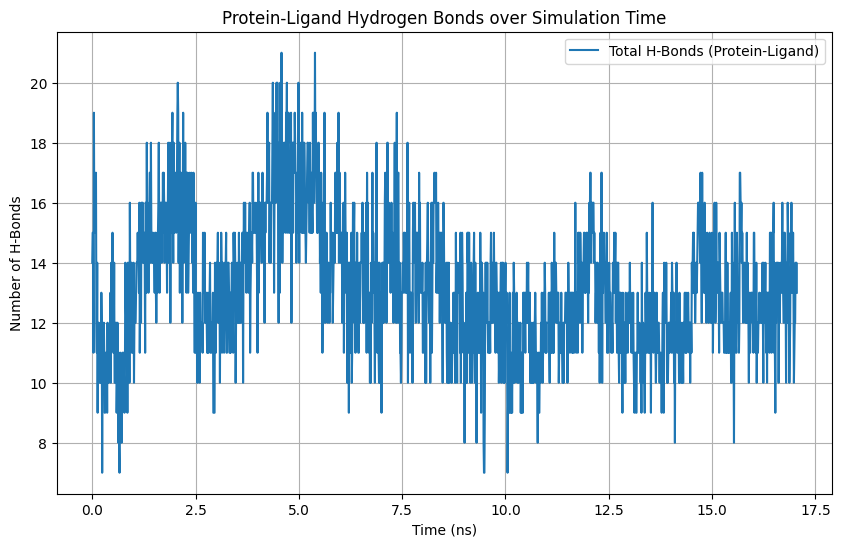

Hydrogen bond data plotted from hb.xvg


In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Define the path to the hb.xvg file
hb_file = 'hb.xvg'

# Initialize lists to store time and HB count data
time = []
hb_count = []

# Read the data from the .xvg file, skipping comments
with open(hb_file, 'r') as f:
    for line in f:
        if line.startswith('#') or line.startswith('@'):
            continue
        parts = line.split()
        if len(parts) == 2:
            try:
                time.append(float(parts[0]))
                hb_count.append(float(parts[1]))
            except ValueError:
                # Skip lines that can't be converted to float
                continue

# Plot the Hydrogen Bond data
plt.figure(figsize=(10, 6))
plt.plot(time, hb_count, label='Total H-Bonds (Protein-Ligand)')
plt.xlabel('Time (ns)')
plt.ylabel('Number of H-Bonds')
plt.title('Protein-Ligand Hydrogen Bonds over Simulation Time')
plt.grid(True)
plt.legend()
plt.show()

print(f"Hydrogen bond data plotted from {hb_file}")

**Copy the Build Files and directories**

In [ ]:
# This step is no longer needed as GROMACS is installed directly to Google Drive
# cp -R /content/gromacs-2026.1 /content/drive/MyDrive/gmx-new

In [ ]:
# This step is no longer needed as GROMACS is installed directly to Google Drive
# cp -R /content/build /content/drive/MyDrive/gmx-new/gromacs-2026.1/

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (1801759002.py, line 1)

In [18]:
!{GMX_BIN} trjconv -s MD.tpr -f MD.gro -o final_100ns.pdb

                     :-) GROMACS - gmx trjconv, 2026.1 (-:

Executable:   /content/drive/MyDrive/gromacs_persistent/bin/gmx
Data prefix:  /content/drive/MyDrive/gromacs_persistent
Working dir:  /content/drive/MyDrive/gmx-new/GROMACS-Protein-Ligand-main 2
Command line:
  gmx trjconv -s MD.tpr -f MD.gro -o final_100ns.pdb

Note that major changes are planned in future for trjconv, to improve usability and utility.
Will write pdb: Protein data bank file
Reading file MD.tpr, VERSION 2026.1 (single precision)
Reading file MD.tpr, VERSION 2026.1 (single precision)
Select group for output
Group     0 (         System) has 65169 elements
Group     1 (        Protein) has  9405 elements
Group     2 (      Protein-H) has  4835 elements
Group     3 (        C-alpha) has   586 elements
Group     4 (       Backbone) has  1758 elements
Group     5 (      MainChain) has  2343 elements
Group     6 (   MainChain+Cb) has  2896 elements
Group     7 (    MainChain+H) has  2901 elements
Group     8 (      